In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
PROJECT_DIR = Path("/workspaces/DBA-ai-trust-score-framework-Interim")

SAMPLE_DIR = PROJECT_DIR / "data" / "samples"

REPORT_DIR = PROJECT_DIR / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

REPORT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

In [5]:
fairface = pd.read_csv(
    SAMPLE_DIR / "fairface" / "metadata.csv"
)

celeba = pd.read_csv(
    SAMPLE_DIR / "celeba" / "metadata.csv"
)

drowsiness = pd.read_csv(
    SAMPLE_DIR / "driver_drowsiness" / "metadata.csv"
)

In [6]:
summary = pd.DataFrame({

    "Dataset":[
        "FairFace",
        "CelebA",
        "Driver Drowsiness"
    ],

    "Images":[
        len(fairface),
        len(celeba),
        len(drowsiness)
    ],

    "Columns":[
        fairface.shape[1],
        celeba.shape[1],
        drowsiness.shape[1]
    ]

})

summary

,Dataset,Images,Columns
0,FairFace,1000,5
1,CelebA,400,1
2,Driver Drowsiness,1000,5


In [7]:
summary.to_csv(
    REPORT_DIR/"dataset_summary.csv",
    index=False
)

_______________________Missing Values________________________

In [8]:
datasets = {
    "FairFace":fairface,
    "CelebA":celeba,
    "Driver Drowsiness":drowsiness,
}

for name,df in datasets.items():

    print("="*60)
    print(name)
    print("="*60)

    print(df.isna().sum())

FairFace
age             0
gender          0
race            0
service_test    0
file_name       0
dtype: int64
CelebA
file_name    0
dtype: int64
Driver Drowsiness
Image_id           0
Left_eye_react     0
Right_eye_react    0
Label              0
file_name          0
dtype: int64


______________________Duplicate Values___________________________

In [9]:
for name,df in datasets.items():

    print(name)

    print(
        "Duplicates:",
        df.duplicated().sum()
    )

FairFace
Duplicates: 0
CelebA
Duplicates: 0
Driver Drowsiness
Duplicates: 0


_______________________Dataset Information______________________________

In [10]:
for name,df in datasets.items():

    print("="*60)
    print(name)
    print("="*60)

    display(df.head())

FairFace


,age,gender,race,service_test,file_name
0,4,0,3,False,fairface_00000.jpg
1,1,1,5,False,fairface_00001.jpg
2,2,1,0,False,fairface_00002.jpg
3,3,1,0,False,fairface_00003.jpg
4,2,0,5,True,fairface_00004.jpg


CelebA


,file_name
0,celeba_00000.jpg
1,celeba_00001.jpg
2,celeba_00002.jpg
3,celeba_00003.jpg
4,celeba_00004.jpg


Driver Drowsiness


,Image_id,Left_eye_react,Right_eye_react,Label,file_name
0,11402,"[279.0, 179.0, 27.0, 10.0]","[216.0, 177.0, 28.0, 10.0]",closed_eyes,driver_drowsiness_00000.jpg
1,9084,"[315.0, 160.0, 35.0, 6.0]","[235.0, 167.0, 34.0, 8.0]",closed_eyes,driver_drowsiness_00001.jpg
2,42790,"[259.0, 215.0, 36.0, 9.0]","[158.0, 217.0, 47.0, 10.0]",closed_eyes,driver_drowsiness_00002.jpg
3,44911,"[230.0, 156.0, 34.0, 8.0]","[164.0, 155.0, 26.0, 6.0]",closed_eyes,driver_drowsiness_00003.jpg
4,66109,"[280.0, 155.0, 28.0, 6.0]","[215.0, 152.0, 28.0, 5.0]",closed_eyes,driver_drowsiness_00004.jpg


_________________________Saving Combined Metadata___________________________

In [13]:
fairface["dataset"]="FairFace"
celeba["dataset"]="CelebA"
drowsiness["dataset"]="Driver Drowsiness"

master_metadata = pd.concat([

    fairface,
    celeba,
    drowsiness   

],
ignore_index=True)

master_metadata.to_csv(

    PROJECT_DIR/
    "data"/
    "processed"/
    "master_metadata.csv",

    index=False
)

master_metadata.head()

,age,gender,race,service_test,file_name,dataset,Image_id,Left_eye_react,Right_eye_react,Label
0,4.0,0.0,3.0,False,fairface_00000.jpg,FairFace,NaN,NaN,NaN,NaN
1,1.0,1.0,5.0,False,fairface_00001.jpg,FairFace,NaN,NaN,NaN,NaN
2,2.0,1.0,0.0,False,fairface_00002.jpg,FairFace,NaN,NaN,NaN,NaN
3,3.0,1.0,0.0,False,fairface_00003.jpg,FairFace,NaN,NaN,NaN,NaN
4,2.0,0.0,5.0,True,fairface_00004.jpg,FairFace,NaN,NaN,NaN,NaN


______________________________________Dataset Distribution__________________________________

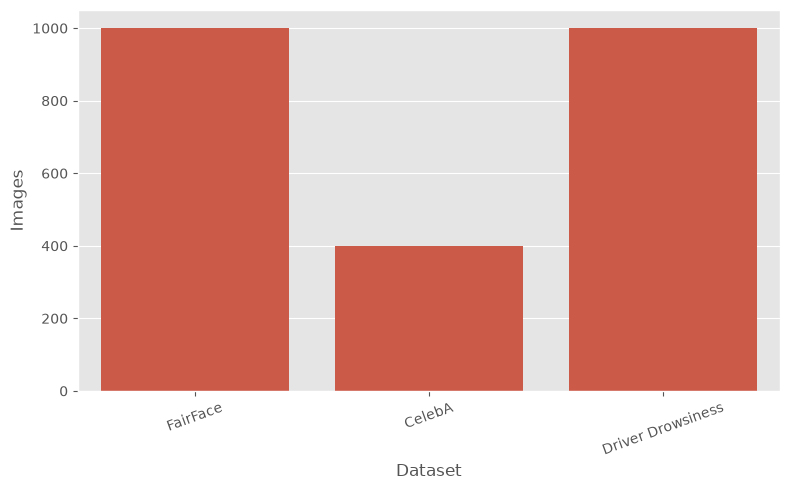

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=summary,
    x="Dataset",
    y="Images"
)

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR/"dataset_distribution.png",
    dpi=300
)

plt.show()

____________________________________Attribute Overview_______________________________________

In [15]:
for name,df in datasets.items():

    print("\n")
    print("="*60)
    print(name)
    print("="*60)

    print(df.columns.tolist())



FairFace
['age', 'gender', 'race', 'service_test', 'file_name', 'dataset']


CelebA
['file_name', 'dataset']


Driver Drowsiness
['Image_id', 'Left_eye_react', 'Right_eye_react', 'Label', 'file_name', 'dataset']


___________________________________Summary Stats______________________________________________

In [16]:
master_metadata.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1000.0,NaN,NaN,NaN,3.484,1.646346,0.0,3.0,3.0,4.0,8.0
gender,1000.0,NaN,NaN,NaN,0.454,0.498129,0.0,0.0,0.0,1.0,1.0
race,1000.0,NaN,NaN,NaN,2.897,1.939111,0.0,1.0,3.0,5.0,6.0
service_test,1000,2,False,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
file_name,2400,2400,fairface_00000.jpg,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,2400,3,FairFace,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Image_id,1000.0,NaN,NaN,NaN,67905.227,36583.300794,127.0,37011.75,71293.5,99313.25,126475.0
Left_eye_react,1000,997,"[341.0, 118.0, 16.0, 4.0]",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Right_eye_react,1000,997,"[177.0, 147.0, 27.0, 8.0]",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Label,1000,2,closed_eyes,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

master_metadata.to_csv(
    PROCESSED_DIR / "master_metadata.csv",
    index=False
)

print("✅ master_metadata.csv saved")

✅ master_metadata.csv saved
